In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))

import src.helper_function as hf

In [2]:
FIG_DIR = Path("../Visualization/Distribution/")
FIG_DIR.mkdir(parents= True, exist_ok= True)

In [3]:
df = pd.read_parquet(
    path="../data/processed/UCI_Credit_Card_Cleaned.parquet"
)

df_raw = pd.read_parquet(
    path="../data/processed/UCI_Credit_Card.parquet"
)

In [4]:
df.groupby('IS_DEFAULT')['LIMIT_BAL'].describe()

,count,mean,std,min,25%,50%,75%,max
IS_DEFAULT,,,,,,,,
0,23364.0,178099.726074,131628.359660,10000.0,70000.0,150000.0,250000.0,1000000.0
1,6636.0,130109.656420,115378.540571,10000.0,50000.0,90000.0,200000.0,740000.0


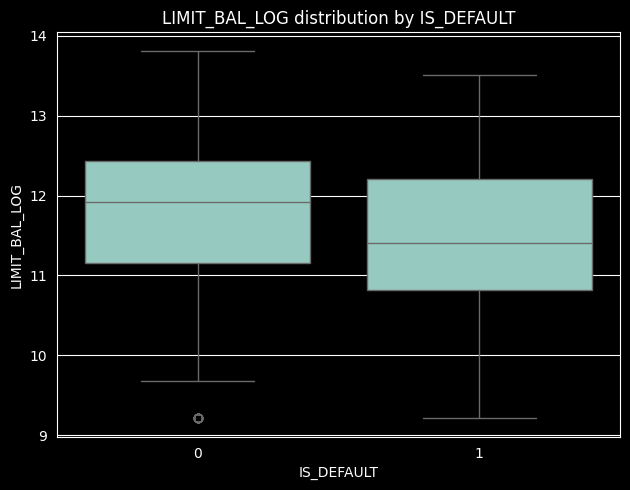

In [5]:
# Boxplot hạn mức tín dụng và nợ xấu
df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])

hf.plot_box(df = df, feature= 'LIMIT_BAL_LOG', save_path= FIG_DIR)

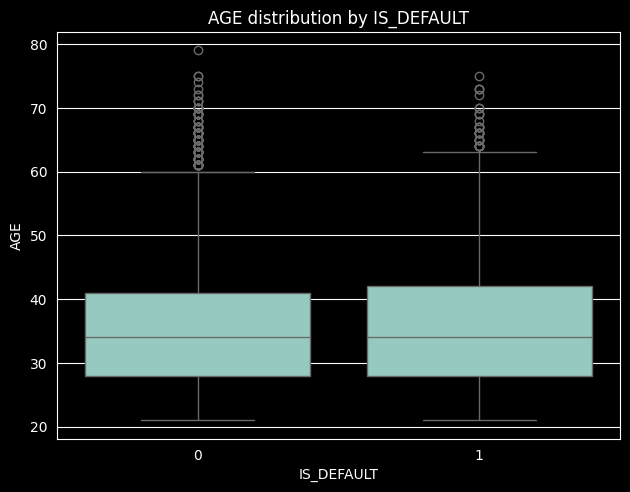

In [6]:
#Biểu đồ hộp giữa tuổi và tình trạng nợ xấu
hf.plot_box(df = df, feature= 'AGE', save_path= FIG_DIR)

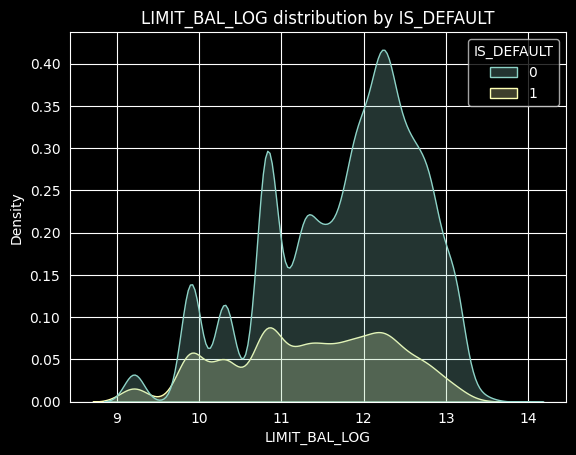

In [7]:
hf.plot_kde(df= df, feature='LIMIT_BAL_LOG', save_path=FIG_DIR)

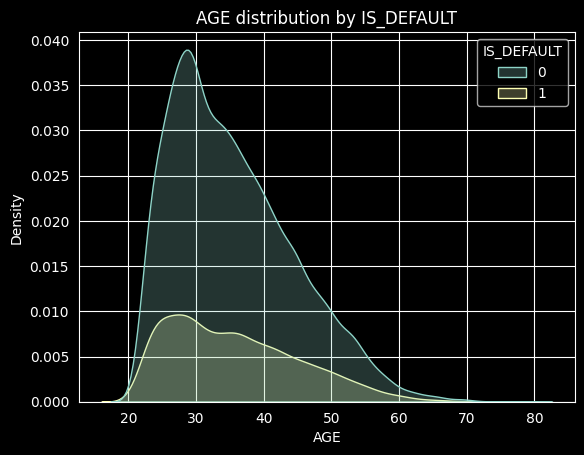

In [8]:
#Phân bố tuổi khách hàng và tình trạng nợ xấu
hf.plot_kde(df= df, feature= 'AGE', save_path= FIG_DIR)

                  ID  LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE  \
ID          1.000000   0.026179  0.018497   0.037074 -0.028208  0.018678   
LIMIT_BAL   0.026179   1.000000  0.024755  -0.232171 -0.111012  0.144713   
SEX         0.018497   0.024755  1.000000   0.014533 -0.028522 -0.090874   
EDUCATION   0.037074  -0.232171  0.014533   1.000000 -0.137626  0.181614   
MARRIAGE   -0.028208  -0.111012 -0.028522  -0.137626  1.000000 -0.412001   
AGE         0.018678   0.144713 -0.090874   0.181614 -0.412001  1.000000   
PAY_1      -0.030575  -0.271214 -0.057643   0.113732  0.018557 -0.039447   
PAY_2      -0.011215  -0.296382 -0.070771   0.131588  0.023620 -0.050148   
PAY_3      -0.018494  -0.286123 -0.066096   0.124089  0.032399 -0.053048   
PAY_4      -0.002735  -0.267460 -0.060173   0.117959  0.031831 -0.049722   
PAY_5      -0.022199  -0.249411 -0.055064   0.105927  0.034377 -0.053826   
PAY_6      -0.020270  -0.235195 -0.044008   0.091359  0.033168 -0.048773   
BILL_AMT1   

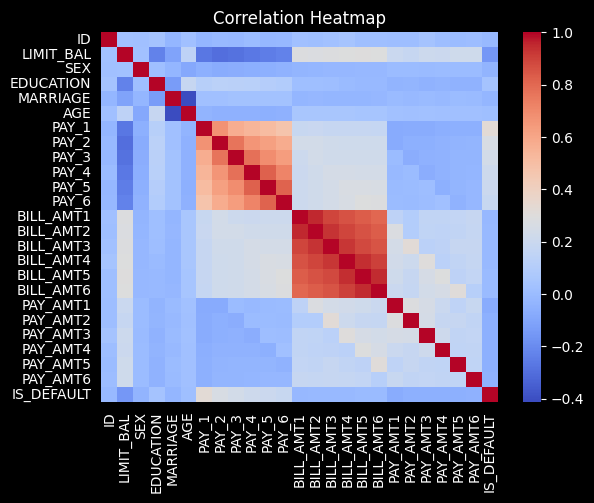

In [9]:
# Heatmap cho payment status: PAY_X
corr = df_raw.corr()

print(corr)

sns.heatmap(corr, annot= False, cmap= "coolwarm")

plt.title("Correlation Heatmap")

hf._save_figure_(FIG_DIR, "CorrelationHeatmap")

plt.show()